In [6]:
import sys, os, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'toy_domain'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'MedGrid'))

import med_grid_env
import gymnasium as gym
from boundary_tracer import BoundaryTracer

RUN_NAME = 'medgrid_cont_scale1'   # change to match -info flag used during training
RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', RUN_NAME)

## 1. Ground truth regions

MedGrid is a **10×10** continuous gridworld with:
* **Red (Death):** quarter-circles of radius 3 at bottom-left $(0,0)$ and top-right $(10,10)$.
* **Yellow (Trap):** annular bands $3 < d \le 5$ around each death zone corner.
* **Blue (Recovery):** a rotated ellipse centred at $(5,5)$, semi-major $a=3$, semi-minor $b=1.5$, tilted $-45°$.
* **White (Neutral):** everything else.
* **Start:** bottom-right corner $(10, 0)$.

/tmp/ipykernel_7123/830847388.py:50: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='white',   label='Neutral', edgecolor='grey'),


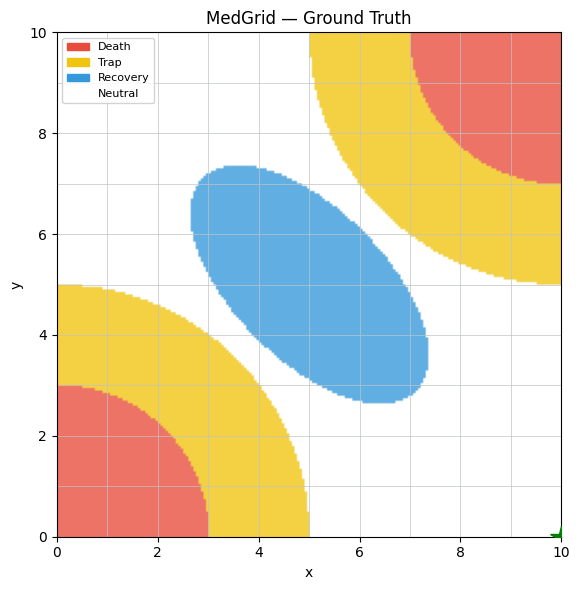

In [7]:
SIZE      = 10.0
DEATH_R   = 3.0
TRAP_R    = 5.0
ELLIPSE_A = 3.0
ELLIPSE_B = 1.5
RESOLUTION = 400

def classify_point(x, y):
    d_bl = np.sqrt(x**2 + y**2)
    d_tr = np.sqrt((x - 10)**2 + (y - 10)**2)
    if d_bl <= DEATH_R or d_tr <= DEATH_R:
        return 'death'
    if d_bl <= TRAP_R or d_tr <= TRAP_R:
        return 'trap'
    dx, dy = x - 5.0, y - 5.0
    if ((dx - dy)**2 / (2 * ELLIPSE_A**2) + (dx + dy)**2 / (2 * ELLIPSE_B**2)) <= 1.0:
        return 'recovery'
    return 'neutral'

def build_region_image(resolution=RESOLUTION):
    COLORS = {
        'death':    np.array([231,  76,  60, 200], dtype=np.uint8),
        'trap':     np.array([241, 196,  15, 200], dtype=np.uint8),
        'recovery': np.array([ 52, 152, 219, 200], dtype=np.uint8),
        'neutral':  np.array([255, 255, 255, 255], dtype=np.uint8),
    }
    xs = np.linspace(0, SIZE, resolution)
    ys = np.linspace(0, SIZE, resolution)
    img = np.zeros((resolution, resolution, 4), dtype=np.uint8)
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            img[j, i] = COLORS[classify_point(x, y)]
    return img

def plot_ground_truth(ax=None, resolution=200):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure
    ax.imshow(build_region_image(resolution), origin='lower',
              extent=[0, SIZE, 0, SIZE], aspect='equal')
    for i in range(11):
        ax.axhline(i, color='#bdc3c7', lw=0.5, zorder=2)
        ax.axvline(i, color='#bdc3c7', lw=0.5, zorder=2)
    ax.plot(10, 0, 'g*', markersize=16, label='Start (10,0)', zorder=5)
    legend_patches = [
        mpatches.Patch(color='#e74c3c', label='Death'),
        mpatches.Patch(color='#f1c40f', label='Trap'),
        mpatches.Patch(color='#3498db', label='Recovery'),
        mpatches.Patch(color='white',   label='Neutral', edgecolor='grey'),
    ]
    ax.legend(handles=legend_patches, loc='upper left', fontsize=8, framealpha=0.85)
    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('MedGrid — Ground Truth')
    return fig, ax

fig, ax = plot_ground_truth()
plt.tight_layout(); plt.show()

## 2. Load trained agents

```bash
cd toy_domain
../.venv/bin/python run.py -env MedGrid -action_mode continuous \
    -agent iqn -ded -frames 500000 -info medgrid_test_cont
```

In [8]:
import io

class CpuUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(
                io.BytesIO(b), map_location=torch.device('cpu'), weights_only=False
            )
        return super().find_class(module, name)

def load_cpu(path):
    with open(path, 'rb') as f:
        return CpuUnpickler(f).load()

agent, qd, qr = None, None, None
try:
    agent = load_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_agent.pkl'))
    print('Loaded main agent')
    qd = load_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_Qd.pkl'))
    qr = load_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_Qr.pkl'))
    print('Loaded Qd and Qr networks')
except FileNotFoundError as e:
    print(f'Agents not found ({e}) — train first.')

Loaded main agent
Loaded Qd and Qr networks


## 3. Predictor-corrector boundary tracing in action space

For a **fixed state** $s$, define:
$$g_D(a) = \mathrm{CVaR}_\eta[Z_D(s,a)] - \delta_D, \qquad g_R(a) = \mathrm{CVaR}_\eta[Z_R(s,a)] - \delta_R$$

The **dead-end boundary** in action space is $\{a : g_D(a) = 0\}$ (actions where the D-network's CVaR exactly equals the threshold).  We trace this curve with the predictor-corrector algorithm instead of densely sampling random actions.

`BoundaryTracer` accepts a `q_fn` callable `(state, action) -> (batch, 1)`, so we pass
`net.get_cvar_deterministic(state, action, alpha=η)` directly — fully differentiable, no
random quantile sampling.

In [9]:
# ── Parameters ───────────────────────────────────────────────────────────────
FIXED_STATE = [10.0, 0.0]   # start corner
ETA         = 0.20          # CVaR level (lower tail fraction)
DELTA_D     = -0.5          # dead-end threshold for Q_d
DELTA_R     =  0.5          # live-end threshold for Q_r
DEVICE      = 'cpu'
M_COARSE    = 15            # coarse grid size for Phase 1

def _prepare_network(ded_agent, device):
    """Move network to device and fix internal device references."""
    net = ded_agent.qnetwork_local
    net.to(device)
    net.device = device
    if hasattr(net, 'pis'):
        net.pis = net.pis.to(device)
    net.eval()
    return net

def make_cvar_fn(network, alpha=ETA):
    """Return a q_fn callable: (state, action) -> CVaR_(alpha) Q  shape (batch,1)."""
    return lambda s, a: network.get_cvar_deterministic(s, a, alpha=alpha)

def _safe_norm(data, vcenter):
    """TwoSlopeNorm guaranteed to satisfy vmin < vcenter < vmax regardless of data range."""
    vmin = min(float(data.min()), vcenter - 1e-4)
    vmax = max(float(data.max()), vcenter + 1e-4)
    return TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

state_t = torch.tensor(FIXED_STATE, dtype=torch.float32)
print(f'State: {FIXED_STATE},  η={ETA},  δ_D={DELTA_D},  δ_R={DELTA_R}')

State: [10.0, 0.0],  η=0.2,  δ_D=-0.5,  δ_R=0.5


In [10]:
comps_d, info_d = None, None
comps_r, info_r = None, None

if qd is not None and qr is not None:
    # ── Trace Q_d boundary: CVaR_η(Q_d(s,a)) = δ_D ───────────────────────────
    net_d = _prepare_network(qd, DEVICE)
    q_fn_d = make_cvar_fn(net_d, alpha=ETA)
    tracer_d = BoundaryTracer(
        net_d, state_t, threshold=DELTA_D,
        action_low=0.0, action_high=10.0,
        device=DEVICE, q_fn=q_fn_d,
    )
    print(f'Tracing Q_d boundary (CVaR_η = {DELTA_D}) with {M_COARSE}×{M_COARSE} coarse grid...')
    comps_d, info_d = tracer_d.run(M=M_COARSE)
    n_pts_d = sum(len(c) for c in comps_d)
    print(f'  {len(comps_d)} component(s), {n_pts_d} boundary points, {info_d["n_evals"]} evaluations')

    # ── Trace Q_r boundary: CVaR_η(Q_r(s,a)) = δ_R ───────────────────────────
    net_r = _prepare_network(qr, DEVICE)
    q_fn_r = make_cvar_fn(net_r, alpha=ETA)
    tracer_r = BoundaryTracer(
        net_r, state_t, threshold=DELTA_R,
        action_low=0.0, action_high=10.0,
        device=DEVICE, q_fn=q_fn_r,
    )
    print(f'Tracing Q_r boundary (CVaR_η = {DELTA_R}) with {M_COARSE}×{M_COARSE} coarse grid...')
    comps_r, info_r = tracer_r.run(M=M_COARSE)
    n_pts_r = sum(len(c) for c in comps_r)
    print(f'  {len(comps_r)} component(s), {n_pts_r} boundary points, {info_r["n_evals"]} evaluations')
else:
    print('Skipped — no trained agents loaded.')

Tracing Q_d boundary (CVaR_η = -0.5) with 15×15 coarse grid...
  2 component(s), 668 boundary points, 3240 evaluations
Tracing Q_r boundary (CVaR_η = 0.5) with 15×15 coarse grid...
  2 component(s), 643 boundary points, 3078 evaluations


Computing background CVaR heatmaps for reference...
  Q_d range: [-1.088, -0.021]  threshold δ_D=-0.5
  Q_r range: [-0.027, 1.011]  threshold δ_R=0.5


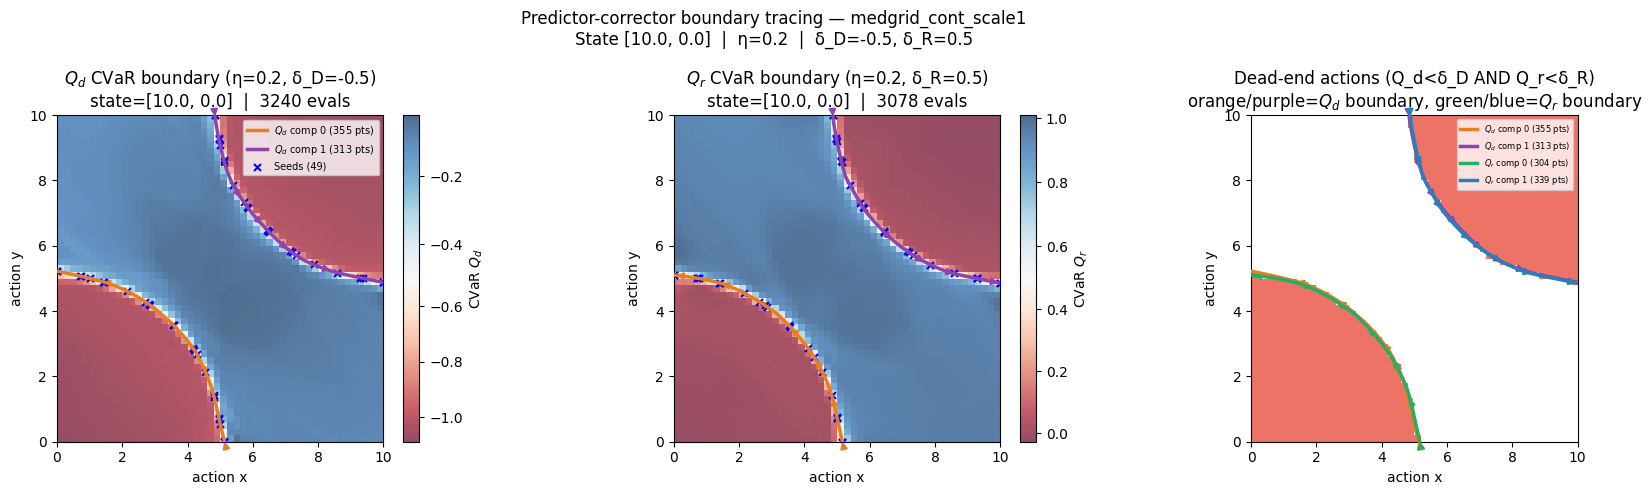

Saved to /home/jay/Uni/SafetyResearch/runs/medgrid_cont_scale1/boundary_tracer_action_space.png


In [11]:
def _eval_cvar_grid(network, state, alpha, resolution, device, size=SIZE):
    """Evaluate CVaR Q on a resolution×resolution grid. Returns (grid, cvar_vals)."""
    pts = np.linspace(0.0, size, resolution, dtype=np.float32)
    xs, ys = np.meshgrid(pts, pts)
    actions = np.column_stack([xs.ravel(), ys.ravel()])
    n = len(actions)
    s_t2 = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0).expand(n, -1)
    a_t  = torch.tensor(actions, dtype=torch.float32, device=device)
    with torch.no_grad():
        q = network.get_cvar_deterministic(s_t2, a_t, alpha=alpha)
    return actions, q[:, 0].cpu().numpy().reshape(resolution, resolution)

def _draw_boundary(ax, components, label_prefix, palette=None):
    """Overlay traced boundary components on an axis with direction arrows."""
    if palette is None:
        palette = ['#e67e22', '#8e44ad', '#27ae60', '#2980b9']
    for ci, comp in enumerate(components):
        if len(comp) < 2:
            continue
        pts2 = np.array(comp)
        col = palette[ci % len(palette)]
        ax.plot(pts2[:, 0], pts2[:, 1], color=col, lw=2.5, zorder=6,
                label=f'{label_prefix} comp {ci} ({len(comp)} pts)')
        step = max(1, len(pts2) // 6)
        for k in range(0, len(pts2) - 1, step):
            ax.annotate('', xy=pts2[k+1], xytext=pts2[k],
                        arrowprops=dict(arrowstyle='-|>', color=col, lw=1.5))

if comps_d is not None:
    HMAP_RES = 50
    a1d = np.linspace(0, SIZE, HMAP_RES)

    print('Computing background CVaR heatmaps for reference...')
    _, hmap_d = _eval_cvar_grid(net_d, FIXED_STATE, ETA, HMAP_RES, DEVICE)
    _, hmap_r = _eval_cvar_grid(net_r, FIXED_STATE, ETA, HMAP_RES, DEVICE)
    print(f'  Q_d range: [{hmap_d.min():.3f}, {hmap_d.max():.3f}]  threshold δ_D={DELTA_D}')
    print(f'  Q_r range: [{hmap_r.min():.3f}, {hmap_r.max():.3f}]  threshold δ_R={DELTA_R}')
    if hmap_d.min() > DELTA_D or hmap_d.max() < DELTA_D:
        print(f'  ⚠  δ_D={DELTA_D} is outside the Q_d range — no boundary exists at this threshold.')
        print(f'     Consider adjusting DELTA_D to a value between {hmap_d.min():.3f} and {hmap_d.max():.3f}.')
    if hmap_r.min() > DELTA_R or hmap_r.max() < DELTA_R:
        print(f'  ⚠  δ_R={DELTA_R} is outside the Q_r range — no boundary exists at this threshold.')
        print(f'     Consider adjusting DELTA_R to a value between {hmap_r.min():.3f} and {hmap_r.max():.3f}.')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Panel 1: Q_d CVaR background + traced boundary ─────────────────────────
    ax = axes[0]
    im = ax.imshow(hmap_d, origin='lower', extent=[0, SIZE, 0, SIZE],
                   cmap='RdBu', norm=_safe_norm(hmap_d, DELTA_D), aspect='equal', alpha=0.7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='CVaR $Q_d$')
    if hmap_d.min() < DELTA_D < hmap_d.max():
        ax.contour(a1d, a1d, hmap_d, levels=[DELTA_D], colors='black',
                   linewidths=1.2, linestyles='--', alpha=0.5)
    _draw_boundary(ax, comps_d, '$Q_d$')
    seeds_d = info_d['seeds_raw']
    if seeds_d:
        sp = np.array(seeds_d)
        ax.scatter(sp[:, 0], sp[:, 1], c='blue', s=25, zorder=5, marker='x',
                   label=f'Seeds ({len(seeds_d)})')
    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('action x'); ax.set_ylabel('action y')
    ax.set_title(
        f'$Q_d$ CVaR boundary (η={ETA}, δ_D={DELTA_D})\n'
        f'state={FIXED_STATE}  |  {info_d["n_evals"]} evals'
    )
    ax.legend(fontsize=7, loc='upper right')

    # ── Panel 2: Q_r CVaR background + traced boundary ─────────────────────────
    ax = axes[1]
    im = ax.imshow(hmap_r, origin='lower', extent=[0, SIZE, 0, SIZE],
                   cmap='RdBu', norm=_safe_norm(hmap_r, DELTA_R), aspect='equal', alpha=0.7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='CVaR $Q_r$')
    if hmap_r.min() < DELTA_R < hmap_r.max():
        ax.contour(a1d, a1d, hmap_r, levels=[DELTA_R], colors='black',
                   linewidths=1.2, linestyles='--', alpha=0.5)
    _draw_boundary(ax, comps_r, '$Q_r$')
    seeds_r = info_r['seeds_raw']
    if seeds_r:
        sp = np.array(seeds_r)
        ax.scatter(sp[:, 0], sp[:, 1], c='blue', s=25, zorder=5, marker='x')
    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('action x'); ax.set_ylabel('action y')
    ax.set_title(
        f'$Q_r$ CVaR boundary (η={ETA}, δ_R={DELTA_R})\n'
        f'state={FIXED_STATE}  |  {info_r["n_evals"]} evals'
    )

    # ── Panel 3: dead-end region = Q_d < δ_D AND Q_r < δ_R ───────────────────
    ax = axes[2]
    dead_mask = (hmap_d < DELTA_D) & (hmap_r < DELTA_R)
    rgba = np.zeros((*dead_mask.shape, 4), dtype=np.uint8)
    rgba[ dead_mask] = [231, 76, 60, 200]
    rgba[~dead_mask] = [255, 255, 255, 220]
    ax.imshow(rgba, origin='lower', extent=[0, SIZE, 0, SIZE], aspect='equal')
    _draw_boundary(ax, comps_d, '$Q_d$', palette=['#e67e22', '#8e44ad'])
    _draw_boundary(ax, comps_r, '$Q_r$', palette=['#27ae60', '#2980b9'])
    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('action x'); ax.set_ylabel('action y')
    ax.set_title(
        f'Dead-end actions (Q_d<δ_D AND Q_r<δ_R)\n'
        f'orange/purple=$Q_d$ boundary, green/blue=$Q_r$ boundary'
    )
    ax.legend(fontsize=6, loc='upper right')

    fig.suptitle(
        f'Predictor-corrector boundary tracing — {RUN_NAME}\n'
        f'State {FIXED_STATE}  |  η={ETA}  |  δ_D={DELTA_D}, δ_R={DELTA_R}',
        fontsize=12
    )
    plt.tight_layout()
    out = os.path.join(RUN_DIR, 'boundary_tracer_action_space.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out)
else:
    print('Skipped — no agents loaded.')